<a href="https://colab.research.google.com/github/Lovie-Tonimba/semester4-DataMining/blob/main/tugasNo3%264Jobsheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import model_selection

from google.colab import drive
drive.mount('/content/drive')

data_raw = pd.read_csv('/content/drive/MyDrive/Data Mining/jobsheet4/diabetes.csv')

Mounted at /content/drive


In [2]:
data1 = data_raw.copy(deep = True)

print('kolom data diabetes dengan nilai NULL:\n', data1.isnull().sum())
print("-"*10)

data_raw.describe(include = 'all')

kolom data diabetes dengan nilai NULL:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
----------


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
columns_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_to_replace:
    data1[col] = data1[col].replace(0, np.nan)

print("Zero values replaced with NaN in specified columns.")
print(data1[columns_to_replace].isnull().sum())

Zero values replaced with NaN in specified columns.
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [6]:
for col in columns_to_replace:
    median_val = data1[col].median()
    data1[col].fillna(median_val, inplace=True)

print("NaN values imputed with median in specified columns.")
print(data1[columns_to_replace].isnull().sum())

NaN values imputed with median in specified columns.
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


/tmp/ipykernel_931/3262086271.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data1[col].fillna(median_val, inplace=True)


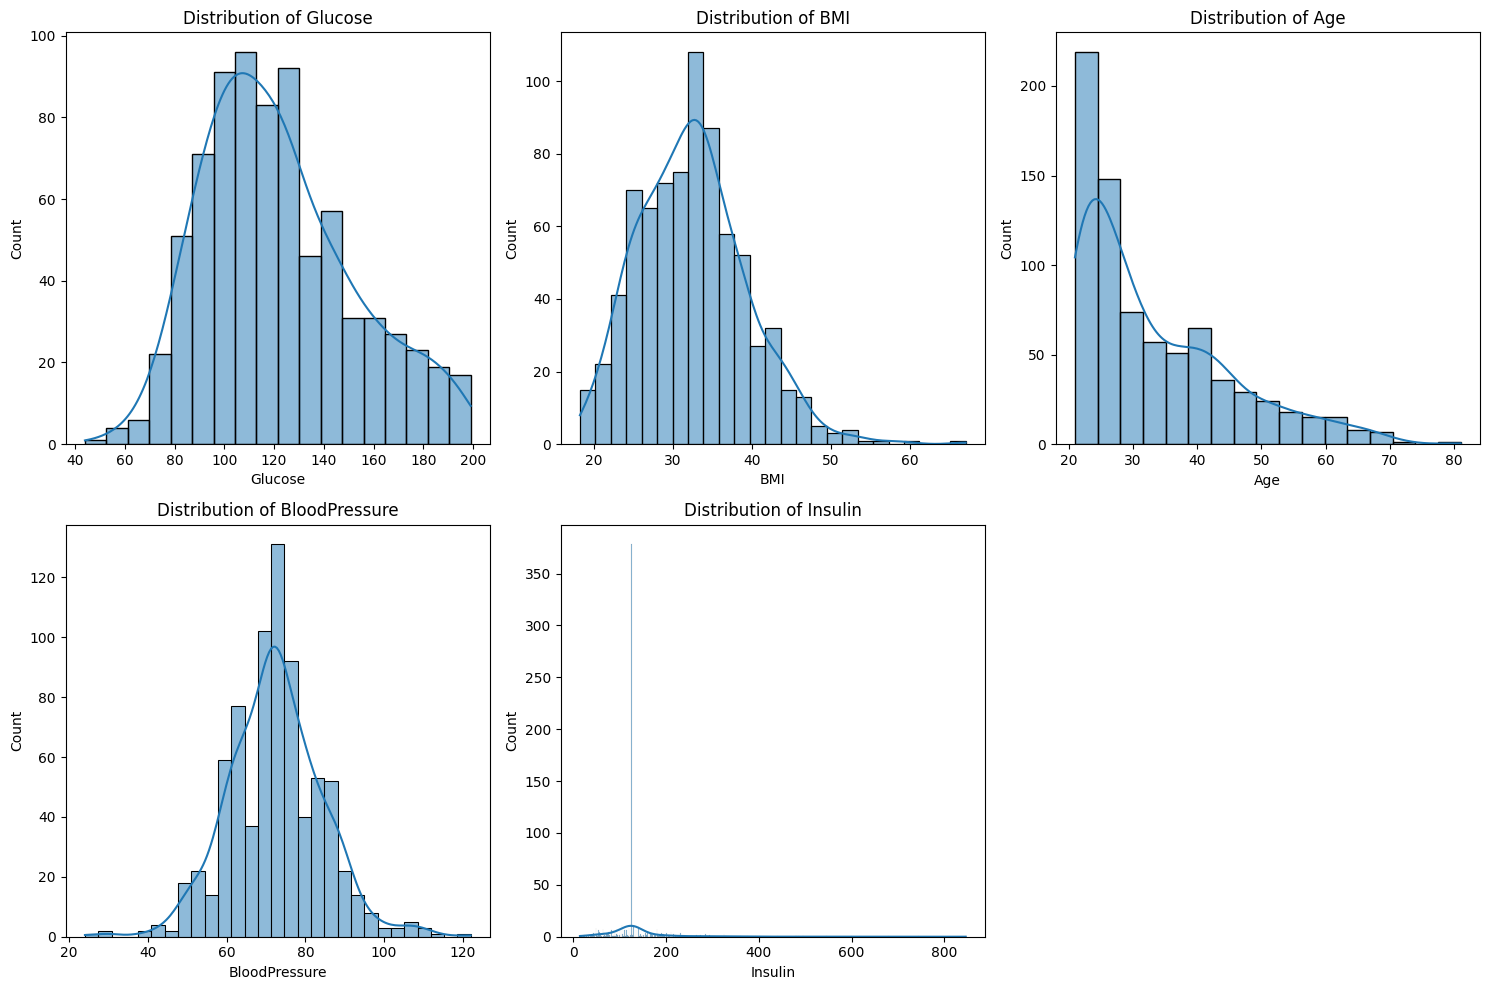

In [7]:
features_to_visualize = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_visualize):
    plt.subplot(2, 3, i + 1) # Create a 2x3 grid of subplots
    sns.histplot(data1[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

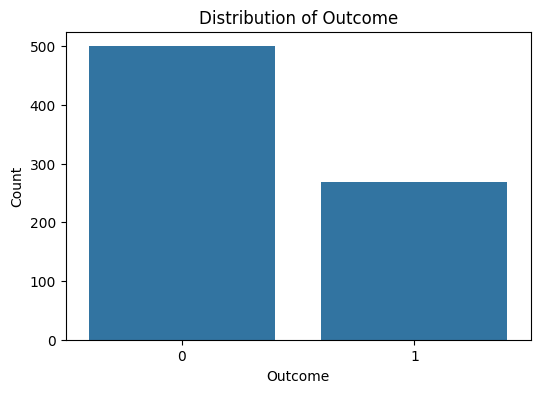

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=data1)
plt.title('Distribution of Outcome')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

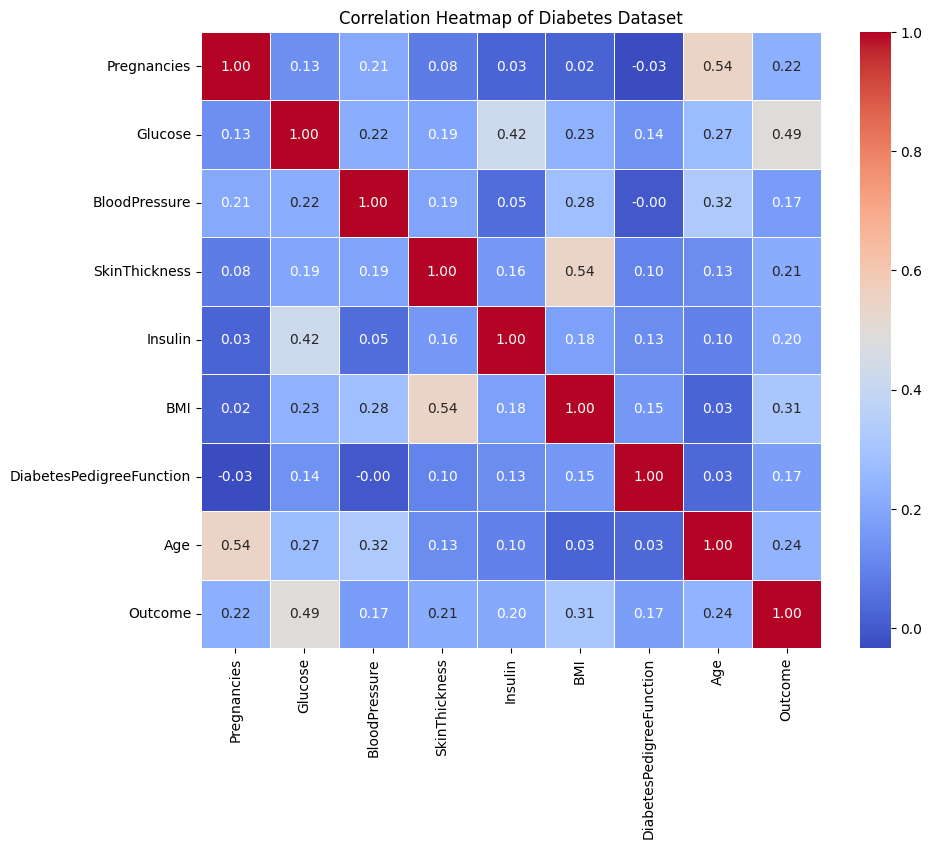

In [9]:
correlation_matrix = data1.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Diabetes Dataset')
plt.show()